In [1]:
import pandas as pd
import numpy as np

# Visualization (optional)
import seaborn as sns
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm, datasets

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#  Real-World Example

Imagine you are a **bank officer** deciding:

 Is a transaction **Fraud (1)** or **Normal (0)**?

---

##  You look at 2 features:
- **Feature 1 →** Transaction Amount  
- **Feature 2 →** Time of transaction  

---

##  Your Job:
 Draw a line that separates **Fraud vs Normal transactions**

---

##  Key Insight:
That’s exactly what this code is doing:

- It takes data (transactions)
- Learns patterns
- Draws a **decision boundary (line)**
- Separates **Fraud** from **Normal**

---

##  In Simple Words:
> The model acts like a smart bank officer who learns from past data and draws a line to detect fraud automatically.

In [2]:


# Create a synthetic dataset (linearly separable)
X, y = datasets.make_blobs(n_samples=100, centers=2, random_state=6)


In [3]:
X

array([[  8.21597398,  -2.28672255],
       [  5.42916264,  -9.28019465],
       [  7.4816983 ,  -2.96403632],
       [  7.93333064,  -3.51553205],
       [  7.29573215,  -4.39392379],
       [  5.73072844,  -2.60895506],
       [  7.9683312 ,  -3.23125265],
       [  6.70309926,  -9.59360762],
       [  7.83762169,  -1.69756104],
       [  7.69483605,  -2.63359393],
       [  6.3649649 ,  -8.97189915],
       [  9.24223825,  -3.88003098],
       [  9.07568367,  -4.21790533],
       [  7.11707557,  -8.20473416],
       [  5.22323107,  -8.27441475],
       [  8.21073365,  -4.00374119],
       [  6.94147717,  -8.23721012],
       [  6.54118443,  -9.84832481],
       [  9.42169269,  -2.6476988 ],
       [  5.97933839,  -9.30802671],
       [  5.20200675,  -8.34325489],
       [  8.07502382,  -4.25949569],
       [  7.80996597,  -4.80944368],
       [  8.03349337,  -2.26578348],
       [  7.20721285,  -9.65948603],
       [  6.36448985,  -9.73455578],
       [  6.47613341,  -9.38565474],
 

In [4]:
y

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1])

In [5]:

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [6]:

# Create a Linear SVM classifier
linear_svm = svm.SVC(kernel='linear')

# Train the model
linear_svm.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_svm.predict(X_test)

In [7]:


# Evaluate accuracy
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Linear SVM Accuracy: {accuracy_linear * 100:.2f}%")


Linear SVM Accuracy: 100.00%


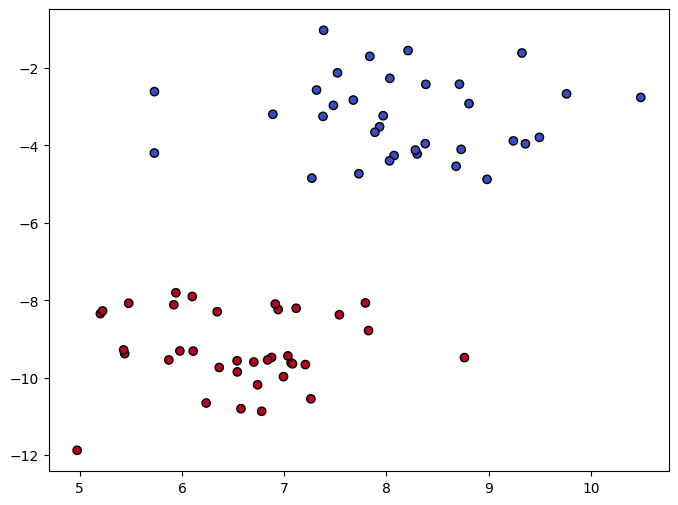

In [8]:

# Plot decision boundary for Linear SVM
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()


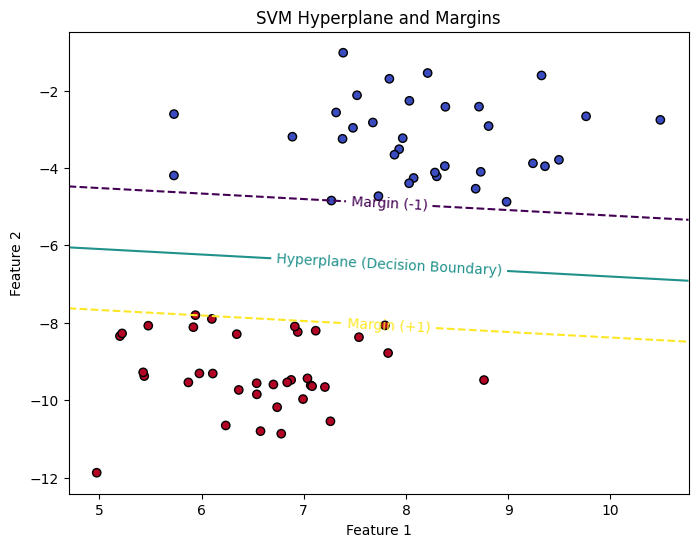

In [9]:
#  Plot Decision Boundary with Labels

plt.figure(figsize=(8, 6))

# Plot data points
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap=plt.cm.coolwarm,
    edgecolors='k'
)

# Get axis limits
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)

# Combine grid points
grid_points = np.vstack([XX.ravel(), YY.ravel()]).T

# Decision function
Z = linear_svm.decision_function(grid_points)
Z = Z.reshape(XX.shape)

# Plot hyperplane and margins
contours = ax.contour(
    XX, YY, Z,
    levels=[-1, 0, 1],
    linestyles=['--', '-', '--']
)

# Label the lines
fmt = {
    -1: "Margin (-1)",
     0: "Hyperplane (Decision Boundary)",
     1: "Margin (+1)"
}
ax.clabel(contours, inline=True, fontsize=10, fmt=fmt)

# Labels and title
plt.title("SVM Hyperplane and Margins")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [10]:

# Create a synthetic dataset (non-linearly separable, e.g., circles)
X, y = datasets.make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=42)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [11]:
#
# Create a non-linear SVM classifier with the RBF kernel
rbf_svm = svm.SVC(kernel='rbf', gamma='scale')  # 'gamma' controls the influence of a single training example

# Train the model
rbf_svm.fit(X_train, y_train)

# Make predictions
y_pred_rbf = rbf_svm.predict(X_test)

In [12]:

# Evaluate accuracy
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Non-linear SVM (RBF) Accuracy: {accuracy_rbf * 100:.1f}%")


Non-linear SVM (RBF) Accuracy: 98.3%


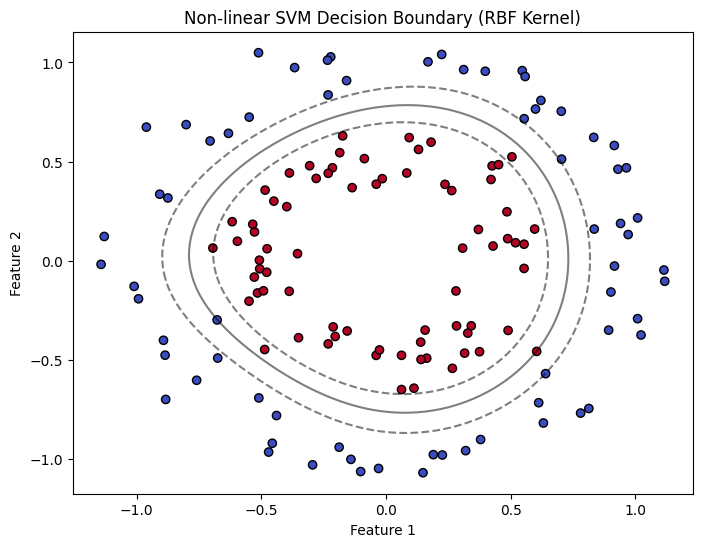

In [13]:


# Plot decision boundary for Non-linear SVM
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = rbf_svm.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-0.5, 0, 0.5], alpha=0.5, linestyles=['--', '-', '--'])
plt.title("Non-linear SVM Decision Boundary (RBF Kernel)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


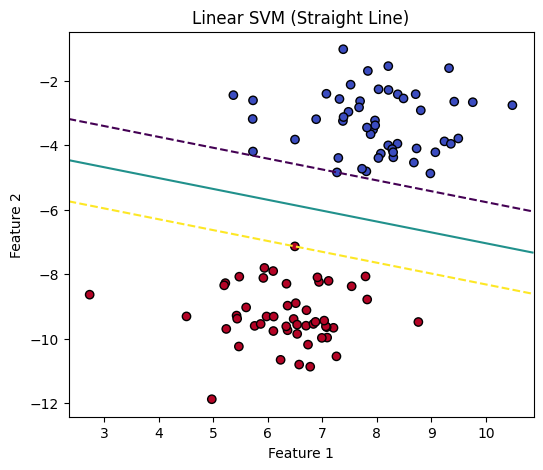

In [14]:

# Create simple linearly separable data
X1, y1 = datasets.make_blobs(n_samples=100, centers=2, random_state=6)

# Train Linear SVM
model1 = svm.SVC(kernel='linear')
model1.fit(X1, y1)

# Plot data
plt.figure(figsize=(6,5))
plt.scatter(X1[:,0], X1[:,1], c=y1, cmap=plt.cm.coolwarm, edgecolors='k')

# Create grid
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)

# Predict on grid
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model1.decision_function(xy).reshape(XX.shape)

# Plot boundary
ax.contour(XX, YY, Z, levels=[-1,0,1], linestyles=['--','-','--'])

plt.title("Linear SVM (Straight Line)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


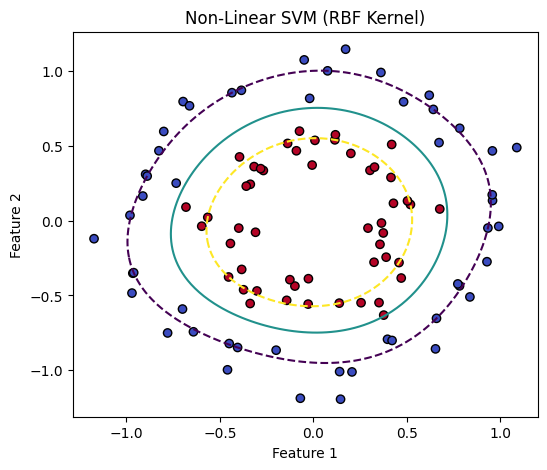

In [15]:

# Create circular data (not linearly separable)
X2, y2 = datasets.make_circles(n_samples=100, factor=0.5, noise=0.1)

# Train RBF SVM
model2 = svm.SVC(kernel='rbf')
model2.fit(X2, y2)

# Plot data
plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1], c=y2, cmap=plt.cm.coolwarm, edgecolors='k')

# Grid
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)

# Predict
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model2.decision_function(xy).reshape(XX.shape)

# Plot curved boundary
ax.contour(XX, YY, Z, levels=[-1,0,1], linestyles=['--','-','--'])

plt.title("Non-Linear SVM (RBF Kernel)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

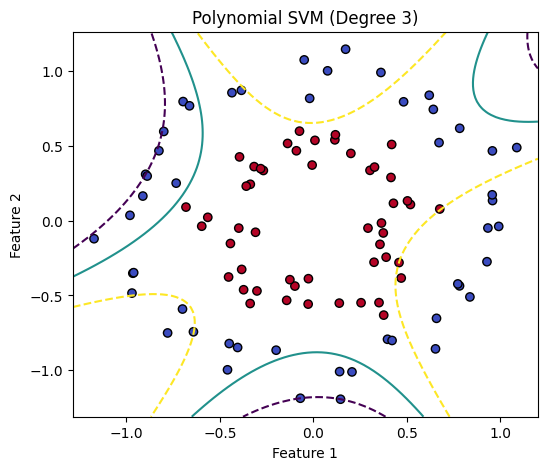

In [16]:



#  POLYNOMIAL SVM

# Use same data
model3 = svm.SVC(kernel='poly', degree=3)
model3.fit(X2, y2)

# Plot data
plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1], c=y2, cmap=plt.cm.coolwarm, edgecolors='k')

# Grid
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)

# Predict
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model3.decision_function(xy).reshape(XX.shape)

# Plot polynomial boundary
ax.contour(XX, YY, Z, levels=[-1,0,1], linestyles=['--','-','--'])

plt.title("Polynomial SVM (Degree 3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


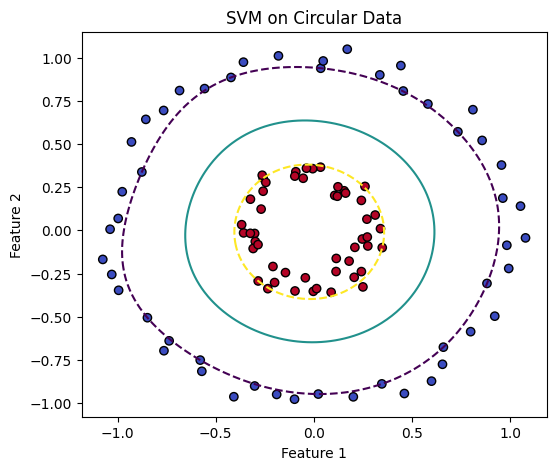

In [17]:

# 4. CIRCULAR DATA (Clear Non-linear Case)

# Create tighter circle data
X3, y3 = datasets.make_circles(n_samples=100, factor=0.3, noise=0.05)

# Train RBF SVM
model4 = svm.SVC(kernel='rbf')
model4.fit(X3, y3)

# Plot data
plt.figure(figsize=(6,5))
plt.scatter(X3[:,0], X3[:,1], c=y3, cmap=plt.cm.coolwarm, edgecolors='k')

# Grid
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)

# Predict
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model4.decision_function(xy).reshape(XX.shape)

# Plot circular boundary
ax.contour(XX, YY, Z, levels=[-1,0,1], linestyles=['--','-','--'])

plt.title("SVM on Circular Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       0.94      0.89      0.91       491
           2       0.91      0.95      0.93       532
           3       0.94      0.98      0.96       496
           4       0.99      0.91      0.95       420
           5       0.93      0.96      0.94       471

    accuracy                           0.95      2947
   macro avg       0.95      0.95      0.95      2947
weighted avg       0.95      0.95      0.95      2947



In [37]:
from sklearn.decomposition import PCA

# Reduce X_train and X_test to 2D
pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(X_train)
X_test_2D = pca.transform(X_test)

In [38]:
from sklearn import svm

svm_model_2D = svm.SVC(kernel='rbf', gamma='scale')
svm_model_2D.fit(X_train_2D, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create meshgrid
x_min, x_max = X_train_2D[:, 0].min() - 1, X_train_2D[:, 0].max() + 1
y_min, y_max = X_train_2D[:, 1].min() - 1, X_train_2D[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict on meshgrid
Z = svm_model_2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_train_2D[:, 0], X_train_2D[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.coolwarm)
plt.title("SVM Decision Boundary (RBF Kernel, 2D PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

Y_pred = svm_model_2D.predict(X_test_2D)

# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# Classification Report
print(classification_report(Y_test, Y_pred))